In [2]:
# Importing stuff

import cv2
import matplotlib.pyplot as plt

print('Successfully install')

Successfully install


Image taken


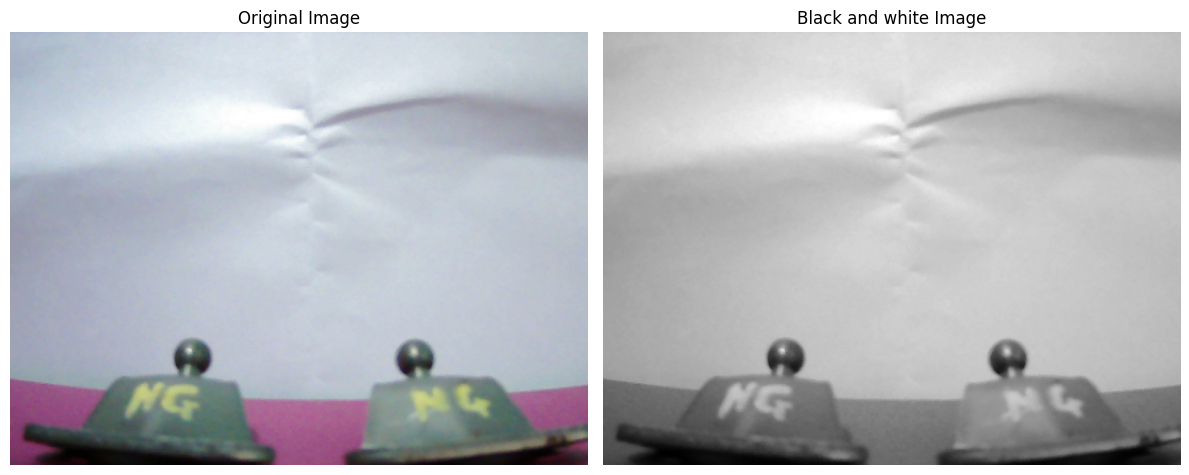

In [2]:
# Open camera
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,800)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT,800)

#Take a picture
ret, frame = cap.read()
cap.release()

if ret:
    # Convert to black and white
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Save the original and B&W picture
    cv2.imwrite("original.jpg", frame)
    cv2.imwrite("blackwhite.jpg", gray)
    
    print("Image taken")

    #Show image side by side

    plt.figure(figsize=(12,6))

    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(frame,cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(gray, cmap = 'gray')
    plt.title("Black and white Image")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    
else:
    print("failed")

In [6]:
# Gaussian blur image

image = cv2.imread('blackwhite.jpg')

blurred_image = cv2.GaussianBlur(image, (11,11),0)

cv2.imwrite("blurred image.jpg", blurred_image)

#cv2.imshow('original image', image)
cv2.imshow('blurred image', blurred_image)

cv2.waitKey(0)
cv2.destroyAllWindows()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-packages/cv2/qt/plugins"
QFontDatabase: Cannot find font directory /home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-pack

In [3]:
# Rect bound

image = cv2.imread('original.jpg', cv2.IMREAD_GRAYSCALE)

thresh_val = 127
max_val = 255

ret,binary_inv = cv2.threshold(image, thresh_val, max_val, cv2.THRESH_BINARY_INV )

cv2.imwrite('gaussian.jpg',binary_inv)

# plt.figure(figsize=(12,6))

# plt.subplot(1,2,1)
# plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
# plt.title('Original image')
# plt.axis('off')

# plt.subplot(1,2,2)
# plt.imshow(cv2.cvtColor(binary_inv, cv2.COLOR_BGR2RGB))
# plt.title('Gaussian Blur')
# plt.axis('off')

# plt.tight_layout()
# plt.show()


contours, hierarchy = cv2.findContours(binary_inv, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

cv2.drawContours(image, contours, -1, (0,255,0),3)

# cv2.imshow('Contours', image)
# cv2.waitKey(0)
# cv2.destroyAllWindows()


for cnt in contours:
    x,y,w,h = cv2.boundingRect(cnt)
    cv2.rectangle(image, (x,y), (x+w,y+h), (0,255,0), 2 )

cv2.imshow("Bounding Boxes",image)
cv2.waitKey(0)
cv2.destroyAllWindows()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-packages/cv2/qt/plugins"
QFontDatabase: Cannot find font directory /home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-pack

In [18]:
# Live Camera feed

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open camera")
    exit()

while True:
    ret, frame = cap.read()

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5,5),0)
    _, thresh = cv2.threshold(blurred,90,255,cv2.THRESH_BINARY_INV)
    contours,_ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max (contours, key=cv2.contourArea)
        
        if cv2.contourArea(largest) > 1000:
            x,y,w,h = cv2.boundingRect(largest)
            cv2.rectangle(frame, (x,y), (x+w,y+h), (0,255,0),3)
            
    
    cv2.imshow('Threshold',thresh)
    
    cv2.imshow('Processed Video',frame)

    if not  ret:
        print('Error: Cant receive frame. Exiting')
        break
        

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()